# <span style="color:#0b486b">  FIT5215: Deep Learning (2025)</span>
***
*CE/Lecturer (Clayton):*  **Dr Trung Le** | trunglm@monash.edu <br/>
*Lecturer (Clayton):* **A/Prof Zongyuan Ge** | zongyuan.ge@monash.edu <br/>
*Lecturer (Malaysia):*  **Dr Arghya Pal** | arghya.pal@monash.edu <br/>
 <br/>
*Head Tutor 3181:*  **Ms Ruda Nie H** |  \[RudaNie.H@monash.edu \] <br/>
*Head Tutor 5215:*  **Ms Leila Mahmoodi** |  \[leila.mahmoodi@monash.edu \]

<br/> <br/>
Faculty of Information Technology, Monash University, Australia
***

# <span style="color:#0b486b">  Student Information</span>
***
Surname: **RAY**  <br/>
Firstname: **RISHABH**    <br/>
Student ID: **34525416**    <br/>
Email: **RRAY0009@STUDENT.MONASH.EDU**    <br/>
Your tutorial time: **TUESDAY, 6PM-8PM**    <br/>
***

# <span style="color:#0b486b">Deep Neural Networks</span>
### Due: <span style="color:red">11:55pm Sunday, 14 September 2025</span>  (Sunday)

#### <span style="color:red">Important note:</span> This is an **individual** assignment. It contributes **20%** to your final mark. Read the assignment instructions carefully.

## <span style="color:#0b486b">What to submit</span>

This assignment is to be completed individually and submitted to Moodle unit site. **By the due date, you are required to submit one  <span style="color:red; font-weight:bold">single zip file, named xxx_assignment01_solution.zip</span> where `xxx` is your student ID, to the corresponding Assignment (Dropbox) in Moodle**. You can use Google Colab to do Assigmnent 1 but you need to save it to an `*.ipynb` file to submit to the unit Moodle.

**More importantly, if you use Google Colab to do this assignment, you need to first make a copy of this notebook on your Google drive**.

***For example, if your student ID is <span style="color:red; font-weight:bold">12356</span>, then gather all of your assignment solution to folder, create a zip file named <span style="color:red; font-weight:bold">123456_assignment01_solution.zip</span> and submit this file.***

Within this zip folder, you **must** submit the following files:
1.	**Assignment01_solution.ipynb**:  this is your Python notebook solution source file.
1.	**Assignment01_output.html**: this is the output of your Python notebook solution *exported* in html format.
1.	Any **extra files or folder** needed to complete your assignment (e.g., images used in your answers).

Since the notebook is quite big to load and work together, one recommended option is to split solution into three parts and work on them seperately. In that case, replace **Assignment01_solution.ipynb** by three notebooks: **Assignment01_Part1_solution.ipynb**, **Assignment01_Part2_solution.ipynb** and **Assignment01_Part3_solution.ipynb**

**You can run your codes on Google Colab. In this case, you have to make a copy of your Google colab notebook including the traces and progresses of model training before submitting.**



## <span style="color:#0b486b">Part 1: Theory and Knowledge Questions</span>
<div style="text-align: right"><span style="color:red; font-weight:bold">[Total marks for this part: 30 points]<span></div>

The first part of this assignment is to demonstrate your knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the lectures and tutorials from weeks 1 to 4**. Going through these materials before attempting this part is highly recommended.

####  <span style="color:red">**Question 1.1**</span> **Activation function plays an important role in modern Deep NNs. For each of the activation functions below, state its output range, find its derivative (show your steps), and plot the activation fuction and its derivative**

<span style="color:red">**(a)**</span> Exponential linear unit (ELU): $\text{ELU}(x)=\begin{cases}
0.1\left(\exp(x)-1\right) & \text{if}\,x\leq0\\
x & \text{if}\,x>0
\end{cases}$
<div style="text-align: right"><span style="color:red">[1.5 points]</span></div>

<span style="color:red">**(b)**</span> Gaussian Error Linear Unit (GELU): $\text{GELU}(x)=x\Phi(x)$ where $\Phi(x)$ is the `probability cummulative function` of the standard Gaussian distribution or $\Phi(x) = \mathbb{P}\left(X\leq x\right)$ where $X \sim N\left(0,1\right)$. In addition, the GELU activation fuction (the link for the [main paper](https://arxiv.org/pdf/1606.08415v5.pdf)) has been widely used in the state-of-the-art Vision for Transformers (e.g., here is the link for [the main ViT paper](https://arxiv.org/pdf/2010.11929v2.pdf)).
<div style="text-align: right"><span style="color:red">[1.5 points]</span></div>

The ELU function is defined as:
$$
\text{ELU}(x) =
\begin{cases}
  \alpha(e^x - 1) & \text{if } x \le 0 \\
  x & \text{if } x > 0
\end{cases}
$$

The step-by-step derivation of the derivative is as follows:
$$
\begin{align*}
  \text{1. For the case where } x > 0: \\
  \frac{d}{dx}(x) &= 1 \\
  \\
  \text{2. For the case where } x < 0: \\
  \frac{d}{dx}(\alpha e^x - \alpha) &= \alpha e^x
\end{align*}
$$

Combining these gives the final piecewise derivative:
$$
\text{ELU}'(x) =
\begin{cases}
  \alpha e^x & \text{if } x \le 0 \\
  1 & \text{if } x > 0
\end{cases}
$$

The GELU function is defined as:
$$ \text{GELU}(x) = x \cdot \Phi(x) $$
We use the product rule, $(uv)' = u'v + uv'$, with $u=x$ and $v=\Phi(x)$.

1.  The derivatives of the components are:
    $$ u' = \frac{d}{dx}(x) = 1 $$
    $$ v' = \frac{d}{dx}(\Phi(x)) = \phi(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2} $$

2.  Applying the product rule gives the final derivative:
    $$
    \begin{align*}
    \text{GELU}'(x) &= (1 \cdot \Phi(x)) + (x \cdot \phi(x)) \\
    &= \Phi(x) + x\phi(x)
    \end{align*}
    $$

In [478]:
# --- MASTER IMPORT CELL ---

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

# Torchvision for datasets and transforms
from torchvision import datasets, transforms

# Data Handling & Plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm # For progress bars

# Math and System
import math
import os
import zipfile
from scipy.stats import norm

# Set plotting to be inline for notebooks
%matplotlib inline

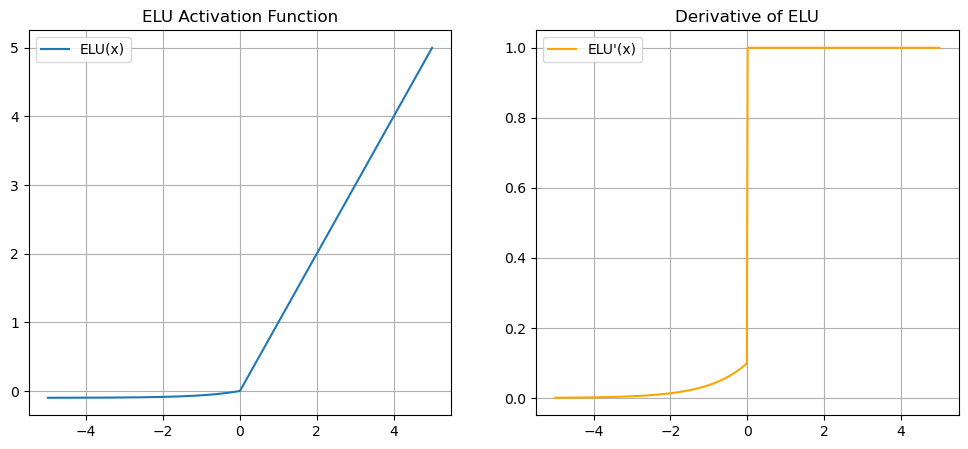

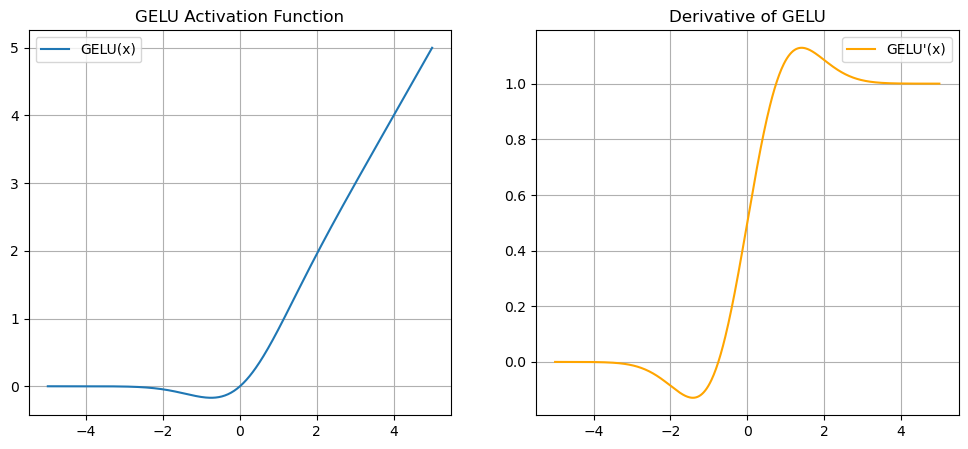

In [588]:
# --- Question 1.1 Code ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set plotting to be inline for notebooks
%matplotlib inline

# --- (a) ELU ---
alpha = 0.1
x_tensor = torch.linspace(-5, 5, 500)
elu = torch.where(x_tensor > 0, x_tensor, alpha * (torch.exp(x_tensor) - 1))
elu_prime = torch.where(x_tensor > 0, torch.ones_like(x_tensor), alpha * torch.exp(x_tensor))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_tensor.numpy(), elu.numpy(), label="ELU(x)")
plt.title("ELU Activation Function")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_tensor.numpy(), elu_prime.numpy(), label="ELU'(x)", color="orange")
plt.title("Derivative of ELU")
plt.grid(True)
plt.legend()
plt.show()

# --- (b) GELU ---
x_np = np.linspace(-5, 5, 500)
pdf = norm.pdf(x_np, 0, 1)
cdf = norm.cdf(x_np, 0, 1)
gelu = x_np * cdf
gelu_prime = cdf + x_np * pdf

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_np, gelu, label="GELU(x)")
plt.title("GELU Activation Function")
plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_np, gelu_prime, label="GELU'(x)", color="orange")
plt.title("Derivative of GELU")
plt.grid(True); plt.legend()
plt.show()

# Question 1.1: Activation Function Output Ranges

### **(a) Exponential Linear Unit (ELU)**

For the given ELU function, $\text{ELU}(x)=\begin{cases} 0.1(\exp(x)-1) & \text{if}\,x\leq0\\ x & \text{if}\,x>0 \end{cases}$:

-   **Output Range:** $[-0.1, \infty)$

As $x$ approaches $-\infty$, $\exp(x)$ approaches 0, making the negative limit $0.1(0-1) = -0.1$. As $x$ increases in the positive direction, the output increases linearly towards $\infty$.

---

### **(b) Gaussian Error Linear Unit (GELU)**

For the GELU function, $\text{GELU}(x)=x\Phi(x)$:

-   **Output Range:** $[-0.17, \infty)$ (approximately)

The function's minimum value is approximately -0.17, and it increases towards $\infty$ for positive values of $x$.

####  <span style="color:red">**Question 1.2:**</span> **Assume that we feed a data point $x$ with a ground-truth label $y=2$ to the feed-forward neural network with the `ReLU activation` function as shown in the following figure**


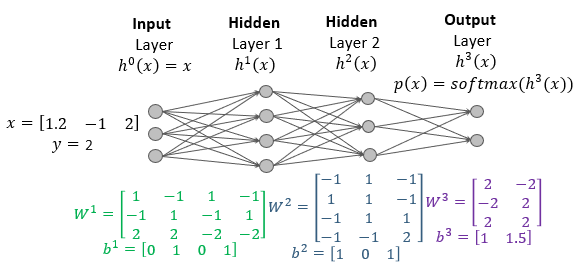

<span style="color:red">**(a)**</span>  What is the numerical value of the latent presentation $h^1(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(b)**</span>  What is the numerical value of the latent presentation $h^2(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(c)**</span>  What is the numerical value of the logit $h^3(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>


<span style="color:red">**(d)**</span>  What is the corresonding prediction probabilities $p(x)$?
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(e)**</span>  What is the predicted label $\widehat{y}$? Is it a correct and an incorect prediction? Remind that $y=2$.
<div style="text-align: right"><span style="color:red">[1 point]</span></div>


<span style="color:red">**(f)**</span>  What is the cross-entropy loss caused by the feed-forward neural network at $(x,y)$? Remind that $y=2$.
<div style="text-align: right"><span style="color:red">[1 point]</span></div>

<span style="color:red">**(g)**</span>  Why is the cross-entropy loss caused by the feed-forward neural network at $(x,y)$ (i.e., $\text{CE}(1_y, p(x))$) always non-negative? When does this $\text{CE}(1_y, p(x))$ loss get the value $0$? Note that you need to answer this question for a general pair $(x,y)$ and a general feed-forward neural network with, for example $M=4$ classes?   
<div style="text-align: right"><span style="color:red">[1 point]</span></div>


*You must show both formulas and numerical results for earning full mark. Although it is optional, it is great if you show your PyTorch code for your computation.*

In [483]:
x = torch.tensor([[1.2, -1.0, 2.0]], dtype=torch.float32)
W1 = torch.tensor([[1,-1,1,-1],[-1,1,-1,1],[2,2,-2,-2]], dtype=torch.float32)
b1 = torch.tensor([0, 1, 0, 1], dtype=torch.float32)
W2 = torch.tensor([[-1,1,-1],[1,1,-1],[-1,1,1],[-1,-1,2]], dtype=torch.float32)
b2 = torch.tensor([1, 0, 1], dtype=torch.float32)
W3 = torch.tensor([[2,-2],[-2,2],[2,2]], dtype=torch.float32)
b3 = torch.tensor([1.0, 1.5], dtype=torch.float32)

# Ground-truth Label (y=2 corresponds to index 1)
y_true_tensor = torch.tensor([1], dtype=torch.long)

# Activation Function
def relu(x):
    return torch.clamp(x, min=0)

#--- Forward Pass Calculations ---
# (a) Latent presentation h^1(x)
a1 = x @ W1 + b1
h1 = relu(a1)
print(f"(a) h^1(x) = {h1.tolist()[0]}")

# (b) Latent presentation h^2(x)
a2 = h1 @ W2 + b2
h2 = relu(a2)
print(f"(b) h^2(x) = {h2.tolist()[0]}")

# (c) Logit h^3(x)
h3 = h2 @ W3 + b3
print(f"(c) h^3(x) = {h3.tolist()[0]}")

# (d) Prediction probabilities p(x)
p = torch.softmax(h3, dim=1)
print(f"(d) p(x) = {p.tolist()[0]}")

# (e) Predicted label y_hat
y_hat = torch.argmax(p, dim=1)
is_correct = "Correct" if y_hat.item() == y_true_tensor.item() else "Incorrect"
print(f"(e) Predicted label y_hat = {y_hat.item()}. This is an {is_correct} prediction.")

# (f) Cross-entropy Loss
loss = F.cross_entropy(h3, y_true_tensor)
print(f"(f) Cross-entropy loss = {loss.item():.4f}")

(a) h^1(x) = [6.199999809265137, 2.799999952316284, 0.0, 0.0]
(b) h^2(x) = [0.0, 9.0, 0.0]
(c) h^3(x) = [-17.0, 19.5]
(d) p(x) = [1.406861638989697e-16, 1.0]
(e) Predicted label y_hat = 1. This is an Correct prediction.
(f) Cross-entropy loss = 0.0000


### (g) Theoretical Explanation

#### Why Cross-Entropy Loss is Always Non-Negative
The cross-entropy loss for a single observation is given by the formula $CE = -\sum_{i=1}^{M} y_i \log(p_i)$, where $y_i$ is 1 if $i$ is the correct class and 0 otherwise, and $p_i$ is the model's predicted probability for class $i$.

For a single correct class $c$, this formula simplifies to $CE = -\log(p_c)$.

The predicted probability $p_c$ is always in the range $[0, 1]$. The logarithm of any value in this range is always less than or equal to zero (i.e., $\log(p_c) \le 0$). Multiplying this non-positive value by -1 ensures the result, the loss, is always **non-negative** ($CE \ge 0$).

#### When the Cross-Entropy Loss is Zero
The loss, $CE = -\log(p_c)$, is equal to **zero** if and only if $\log(p_c) = 0$. This condition is only met when the argument of the logarithm is exactly 1.

Therefore, the loss is zero only when the model assigns a probability of **$p_c = 1$** to the correct class. This signifies a perfect prediction where the model is maximally confident and assigns 0 probability to all other incorrect classes.

####  <span style="color:red">**Question 1.3:**</span>
For **Question 1.3**, you have two options:
* **(1)** *perform the forward, backward propagation, and SGD update for `one mini-batch`* (**10 points**), or
* **(2)** *manually implement a feed-forward neural network* that can work on real tabular datasets (**20 points**).

You can choose either **(1)** or **(2)** to proceed.   

### <span style="color:red">**Option 2**</span>
<div style="text-align: right"><span style="color:red; font-weight:bold">[Total marks for this option: 20 points]<span></div>

In [508]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

**In Option 2, you need to implement a feed-forward NN manually using PyTorch and auto-differentiation of PyTorch. We then manually train the model on the MNIST dataset**.

We first download the `MNIST` dataset and preprocess it.

In [511]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a tensor with shape [C, H, W]
    transforms.Normalize((0.5,), (0.5,)),  # Normalize to [-1, 1]
    transforms.Lambda(lambda x: x.view(28*28)) # Flatten the tensor to shape [-1,HW]
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data, train_labels = train_dataset.data, train_dataset.targets
test_data, test_labels = test_dataset.data, test_dataset.targets
print(train_data.shape, train_labels.shape)
print(test_data.shape, test_labels.shape)

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])


Each data point has dimension `[28,28]`. We need to flatten it to a vector to input to our FFN.

In [513]:
train_dataset.data = train_data.data.reshape(-1, 28*28)
test_dataset.data = test_data.data.reshape(-1, 28*28)

train_data, train_labels = train_dataset.data, train_dataset.targets
test_data, test_labels = test_dataset.data, test_dataset.targets
print(train_data.shape, train_labels.shape)
print(test_data.shape, test_labels.shape)

torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])


We split the train and test sets into many mini-batches of 64.

In [515]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

**Develop the feed-forward neural networks**

**(a)** You need to develop the class `MyLinear` with the following skeleton. You need to declare the weight matrix and bias of this linear layer.

<div style="text-align: right"><span style="color:red">[3 points]</span></div>

In [517]:
class MyLinear(torch.nn.Module):
  def __init__(self, input_size, output_size):
    """
    input_size: the size of the input
    output_size: the size of the output
    """
    super().__init__()
    self.W = torch.nn.Parameter(torch.randn(input_size, output_size) * 0.01)
    self.b = torch.nn.Parameter(torch.zeros(output_size))

  #forward propagation
  def forward(self, x): #x is a mini-batch
    return x @ self.W + self.b

**(b)** You need to develop the class `MyFFN` with the following skeleton

<div style="text-align: right"><span style="color:red">[7 points]</span></div>

In [519]:
class MyFFN(torch.nn.Module):
    def __init__(self, input_size, num_classes, hidden_sizes, act=torch.nn.ReLU()):
        """
        input_size: the size of the input
        num_classes: the number of classes
        act is the activation function
        hidden_sizes is the list of hidden sizes
        for example input_size = 3, hidden_sizes = [5, 7], num_classes = 4, and act = torch.nn.ReLU()
        means that we are building up a FFN with the confirguration
        (3 (Input) -> 5 (ReLU) -> 7 (ReLU) -> 4 (Output))
        """
        super(MyFFN, self).__init__()
        self.input_size = input_size
        self.num_classes = num_classes
        self.act = act
        self.hidden_sizes = hidden_sizes
        self.layers = nn.ModuleList()
    
    def create_FFN(self):
        """
        This function creates the feed-forward neural network
        We stack many MyLinear layers
        """
        all_sizes = [self.input_size] + self.hidden_sizes + [self.num_classes]
        for i in range(len(all_sizes) - 1):
            self.layers.append(MyLinear(all_sizes[i], all_sizes[i+1]))
            if i < len(all_sizes) - 2:
                self.layers.append(self.act)
    
    
    def forward(self,x):
        """
        This implements the forward propagation of the batch x
        This needs to return the logits of x
        """
        out = x
        for layer in self.layers:
            out = layer(out)
        return out
    
    
    def compute_loss(self, x, y):
        """
        This function computes the cross-entropy loss
        You can use the built-in CE loss of PyTorch
        """
        logits = self.forward(x)
        return F.cross_entropy(logits, y)
    
    def update_SGD(self, x, y, learning_rate = 0.01):
        """
        This function updates the model parameters using SGD using the batch (x,y)
        You need to implement the update rule manually and cannot rely on the built-in optimizer
        """
        loss = self.compute_loss(x, y)
        loss.backward()
        with torch.no_grad():
            for m in self.layers:
                if isinstance(m, MyLinear):
                    m.W -= learning_rate * m.W.grad
                    m.b -= learning_rate * m.b.grad
                    m.W.grad.zero_()
                    m.b.grad.zero_()
        return loss.item()
    
    def update_SGDwithMomentum(self, x, y, learning_rate = 0.01, momentum = 0.9):
        """
        This function updates the model parameters using SGD with momentum using the batch (x,y)
        You need to implement the update rule manually and cannot rely on the built-in optimizer
        """
        if not hasattr(self, "_vel"):
            self._vel = {}
            for i, m in enumerate(self.layers):
                if isinstance(m, MyLinear):
                    self._vel[i] = {"W": torch.zeros_like(m.W), "b": torch.zeros_like(m.b)}
        
        loss = self.compute_loss(x, y)
        loss.backward()
        with torch.no_grad():
            for i, m in enumerate(self.layers):
                if isinstance(m, MyLinear):
                    # v_t = gamma * v_{t-1} + grad
                    self._vel[i]["W"] = momentum * self._vel[i]["W"] + m.W.grad
                    self._vel[i]["b"] = momentum * self._vel[i]["b"] + m.b.grad
                    # w_t = w_{t-1} - lr * v_t
                    m.W -= learning_rate * self._vel[i]["W"]
                    m.b -= learning_rate * self._vel[i]["b"]
                    m.W.grad.zero_()
                    m.b.grad.zero_()
        return loss.item()
    
    def update_AdaGrad(self, x, y, learning_rate = 0.01):
        """
        This function updates the model parameters using AdaGrad using the batch (x,y)
        You need to implement the update rule manually and cannot rely on the built-in optimizer
        """
        eps = 1e-8
        if not hasattr(self, "_G"):
            self._G = {}
            for i, m in enumerate(self.layers):
                if isinstance(m, MyLinear):
                    self._G[i] = {"W": torch.zeros_like(m.W), "b": torch.zeros_like(m.b)}
        
        loss = self.compute_loss(x, y)
        loss.backward()
        with torch.no_grad():
            for i, m in enumerate(self.layers):
                if isinstance(m, MyLinear):
                    # G_t = G_{t-1} + grad^2
                    self._G[i]["W"] += m.W.grad ** 2
                    self._G[i]["b"] += m.b.grad ** 2
                    # w_t = w_{t-1} - (lr / sqrt(G_t + eps)) * grad
                    m.W -= learning_rate * m.W.grad / (torch.sqrt(self._G[i]["W"]) + eps)
                    m.b -= learning_rate * m.b.grad / (torch.sqrt(self._G[i]["b"]) + eps)
                    m.W.grad.zero_()
                    m.b.grad.zero_()
        return loss.item()

In [520]:
myFFN = MyFFN(input_size=28*28, num_classes=10, hidden_sizes=[100, 100], act=nn.ReLU())
myFFN.create_FFN()
print(myFFN)

MyFFN(
  (act): ReLU()
  (layers): ModuleList(
    (0): MyLinear()
    (1): ReLU()
    (2): MyLinear()
    (3): ReLU()
    (4): MyLinear()
  )
)


**(c)** Write the code to evaluate the accuracy of the current `myFFN` model on a data loader (e.g., train_loader or test_loader).

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [522]:
def compute_acc(model, data_loader):
  """
  This function computes the accuracy of the model on a data loader
  """
  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
      for x, y in data_loader:
          logits = model.forward(x)
          _, predicted = torch.max(logits.data, 1)
          correct += (predicted == y).sum().item()
          total += y.size(0)
  model.train()
  return correct / total

train_acc = compute_acc(myFFN, train_loader)
print("Train accuracy:", train_acc)

test_acc = compute_acc(myFFN, test_loader)
print("Test accuracy:", test_acc)

Train accuracy: 0.11035
Test accuracy: 0.1097


**(d)** Write the code to evaluate the loss of the current `myFFN` model on a data loader (e.g., train_loader or test_loader).

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [524]:
def compute_loss(model, data_loader):
  """
  This function computes the loss of the model on a data loader
  """
  model.eval()
  total_loss, total_n = 0.0, 0
  with torch.no_grad():
      for x, y in data_loader:
          loss = model.compute_loss(x, y)
          total_loss += loss.item() * y.size(0)
          total_n += y.size(0)
  model.train()
  return total_loss / total_n

train_loss = compute_loss(myFFN, train_loader)
print("Train Loss:", train_loss)

test_loss = compute_loss(myFFN, test_loader)
print("Test Loss:", test_loss)

Train Loss: 2.302527509943644
Test Loss: 2.3025217430114746


Train on the `MNIST` data with 50 epochs using `updateSGD`.

In [526]:
torch.manual_seed(42)
myFFN_sgd = MyFFN(input_size=28*28, num_classes=10, hidden_sizes=[100, 100], act=nn.ReLU())
myFFN_sgd.create_FFN()
print("\n--- Training with Manual SGD ---")
num_epochs = 50
for epoch in range(num_epochs):
    for i, (x, y) in enumerate(train_loader):
      myFFN_sgd.update_SGD(x, y, learning_rate=0.01)
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        train_acc = compute_acc(myFFN_sgd, train_loader)
        test_acc = compute_acc(myFFN_sgd, test_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Acc: {train_acc*100:.2f}%, Test Acc: {test_acc*100:.2f}%")


--- Training with Manual SGD ---
Epoch 5/50, Train Acc: 88.62%, Test Acc: 88.27%
Epoch 10/50, Train Acc: 92.78%, Test Acc: 92.53%
Epoch 15/50, Train Acc: 93.85%, Test Acc: 93.71%
Epoch 20/50, Train Acc: 96.16%, Test Acc: 95.89%
Epoch 25/50, Train Acc: 96.82%, Test Acc: 96.07%
Epoch 30/50, Train Acc: 97.49%, Test Acc: 96.64%
Epoch 35/50, Train Acc: 97.95%, Test Acc: 96.94%
Epoch 40/50, Train Acc: 98.16%, Test Acc: 96.84%
Epoch 45/50, Train Acc: 98.56%, Test Acc: 97.30%
Epoch 50/50, Train Acc: 98.71%, Test Acc: 97.35%


**(e)** Implement the function `updateSGDMomentum` in the class and train the model with this optimizer in `50` epochs. You can update the corresponding function in the `MyFNN` class.

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [528]:
torch.manual_seed(42)
myFFN_mom = MyFFN(input_size=28*28, num_classes=10, hidden_sizes=[100, 100], act=nn.ReLU())
myFFN_mom.create_FFN()
print("\n--- Training with Manual SGD + Momentum ---")
num_epochs = 50
for epoch in range(num_epochs):
    for i, (x, y) in enumerate(train_loader):
        myFFN_mom.update_SGDwithMomentum(x, y, learning_rate=0.01, momentum=0.9)
    if (epoch + 1) % 5 == 0:
        train_acc = compute_acc(myFFN_mom, train_loader)
        test_acc = compute_acc(myFFN_mom, test_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Acc: {train_acc*100:.2f}%, Test Acc: {test_acc*100:.2f}%")


--- Training with Manual SGD + Momentum ---
Epoch 5/50, Train Acc: 97.35%, Test Acc: 96.74%
Epoch 10/50, Train Acc: 98.33%, Test Acc: 97.18%
Epoch 15/50, Train Acc: 99.23%, Test Acc: 97.53%
Epoch 20/50, Train Acc: 99.32%, Test Acc: 97.77%
Epoch 25/50, Train Acc: 99.72%, Test Acc: 97.92%
Epoch 30/50, Train Acc: 99.76%, Test Acc: 97.93%
Epoch 35/50, Train Acc: 99.92%, Test Acc: 97.90%
Epoch 40/50, Train Acc: 99.99%, Test Acc: 98.16%
Epoch 45/50, Train Acc: 100.00%, Test Acc: 98.23%
Epoch 50/50, Train Acc: 100.00%, Test Acc: 98.17%


**(f)** Implement the function `updateAdagrad` in the class and train the model with this optimizer in `50` epochs. You can update the corresponding function in the `MyFNN` class.

<div style="text-align: right"><span style="color:red">[2.5 points]</span></div>

In [530]:
torch.manual_seed(42)
myFFN_ada = MyFFN(input_size=28*28, num_classes=10, hidden_sizes=[100, 100], act=nn.ReLU())
myFFN_ada.create_FFN()
print("\n--- Training with Manual AdaGrad ---")
num_epochs = 50
for epoch in range(num_epochs):
    for i, (x, y) in enumerate(train_loader):
        myFFN_ada.update_AdaGrad(x, y, learning_rate=0.01)
    if (epoch + 1) % 5 == 0:
        train_acc = compute_acc(myFFN_ada, train_loader)
        test_acc = compute_acc(myFFN_ada, test_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Acc: {train_acc*100:.2f}%, Test Acc: {test_acc*100:.2f}%")


--- Training with Manual AdaGrad ---
Epoch 5/50, Train Acc: 93.39%, Test Acc: 93.28%
Epoch 10/50, Train Acc: 94.70%, Test Acc: 94.51%
Epoch 15/50, Train Acc: 95.29%, Test Acc: 95.05%
Epoch 20/50, Train Acc: 95.78%, Test Acc: 95.50%
Epoch 25/50, Train Acc: 96.03%, Test Acc: 95.64%
Epoch 30/50, Train Acc: 96.30%, Test Acc: 95.79%
Epoch 35/50, Train Acc: 96.54%, Test Acc: 95.96%
Epoch 40/50, Train Acc: 96.64%, Test Acc: 96.20%
Epoch 45/50, Train Acc: 96.88%, Test Acc: 96.23%
Epoch 50/50, Train Acc: 97.01%, Test Acc: 96.20%


## <span style="color:#0b486b">Part 2: Deep Neural Networks (DNN) </span>
<div style="text-align: right"><span style="color:red; font-weight:bold">[Total marks for this part: 25 points]<span></div>

The second part of this assignment is to demonstrate your basis knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the tutorials covered from weeks 1 to 2**. Going through these materials before attempting this assignment is highly recommended.

In the second part of this assignment, you are going to work with the FashionMNIST dataset for the image recognition task. It has the exact same format as MNIST (70,000 grayscale images of 28 × 28 pixels each with 10 classes), but the images represent fashion items rather than handwritten digits, so each class is more diverse, and the problem is significantly more challenging than MNIST.

In [533]:
# --- Setup: Imports and Data Loading for FashionMNIST ---
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from tqdm.notebook import tqdm
from copy import deepcopy

**Load the Fashion MNIST using `torchvision`**

In [535]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset_orgin = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

print(train_dataset_orgin.data.shape, train_dataset_orgin.targets.shape)
print(test_dataset.data.shape, test_dataset.targets.shape)

# Flatten the data
train_dataset_orgin.data = train_dataset_orgin.data.reshape(-1, 28*28)
test_dataset.data = test_dataset.data.reshape(-1, 28*28)

print(train_dataset_orgin.data.shape, train_dataset_orgin.targets.shape)
print(test_dataset.data.shape, test_dataset.targets.shape)

N = len(train_dataset_orgin)
print(f"Number of training samples: {N}")
N_train = int(0.9*N)
N_val = N - N_train
print(f"Number of training samples: {N_train}")
print(f"Number of validation samples: {N_val}")

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset_orgin, [N_train, N_val])


print(len(train_dataset))
print(len(val_dataset))


train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])
torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])
Number of training samples: 60000
Number of training samples: 54000
Number of validation samples: 6000
54000
6000


####  <span style="color:red">**Question 2.1:**</span> Write the code to visualize a mini-batch in `train_loader` including its images and labels.

<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>

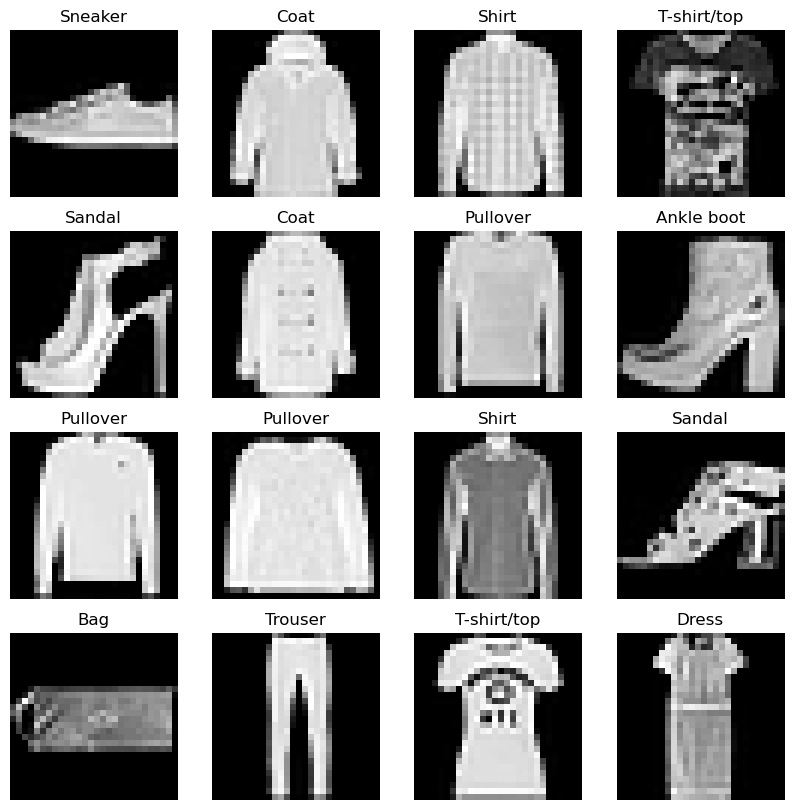

In [537]:
# Class names for FashionMNIST labels
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get one mini-batch of training data
images, labels = next(iter(train_loader))

# Plot the first 16 images from the batch in a 4x4 grid
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    # Un-normalize the image before displaying: (image * std) + mean
    plt.imshow(images[i].view(28, 28) * 0.5 + 0.5, cmap='gray')
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.show()

####<span style="color:red">**Question 2.2:**</span> Write the code for the feed-forward neural net using PyTorch

<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>

We now develop a feed-forward neural network with the architecture $784 \rightarrow 40(ReLU) \rightarrow 30(ReLU) \rightarrow 10(softmax)$. You can choose your own way to implement your network and an optimizer of interest. You should train model in $50$ epochs and evaluate the trained model on the test set.

In [549]:
# --- Question 2.2: FFN Implementation and Training ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1234)

class FFN_2_2(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the layers as specified in the architecture
        self.fc1 = nn.Linear(784, 40) # Input layer: 28*28=784 features
        self.fc2 = nn.Linear(40, 30)  # Hidden layer
        self.fc3 = nn.Linear(30, 10)  # Output layer: 10 classes

    def forward(self, x):
        # Flatten the input image tensor
        x = x.view(x.shape[0], -1)
        # Apply ReLU activation function to the hidden layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # The final layer outputs logits (raw scores), as CrossEntropyLoss applies softmax internally
        x = self.fc3(x)
        return x

# Helper function to compute accuracy
def compute_accuracy(model, loader, device):
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            _, predicted = torch.max(outputs.data, 1)
            total += yb.size(0)
            correct += (predicted == yb).sum().item()
    model.train() # Set model back to training mode
    return correct / total

# --- Training Loop ---
torch.manual_seed(1234)
model_2_2 = FFN_2_2().to(device)
optimizer = torch.optim.Adam(model_2_2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
num_epochs = 50

print("--- Starting Training for Question 2.2 ---")
for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    model_2_2.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model_2_2(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# --- Final Evaluation ---
test_accuracy = compute_accuracy(model_2_2, test_loader, device)
print(f"\n--- Training Complete ---")
print(f"Final Test Accuracy for Q2.2 Model: {test_accuracy*100:.2f}%")

--- Starting Training for Question 2.2 ---


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]


--- Training Complete ---
Final Test Accuracy for Q2.2 Model: 86.97%


####  <span style="color:red">**Question 2.3:**</span> Tuning hyper-parameters with grid search
<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>


Assume that you need to tune the number of neurons on the first and second hidden layers $n_1 \in \{20, 40\}$, $n_2 \in \{20, 40\}$  and the used activation function  $act \in \{sigmoid, tanh, relu\}$. The network has the architecture pattern $784 \rightarrow n_1 (act) \rightarrow n_2(act) \rightarrow 10(softmax)$ where $n_1, n_2$, and $act$ are in their grides. Write the code to tune the hyper-parameters $n_1, n_2$, and $act$. Note that you can freely choose the optimizer and learning rate of interest for this task.

In [552]:
import torch
import torch.nn as nn
import pandas as pd
from tqdm.notebook import tqdm 

if torch.cuda.is_available():
    print(f"✅ Success! GPU found: {torch.cuda.get_device_name(0)}")
else:
    print("❌ Failure. CUDA is not available. Check your hardware, drivers, and PyTorch installation.")

# --- Question 2.3: Grid Search for Hyper-parameters ---

# Flexible network for grid search
class GridSearchNet(nn.Module):
    def __init__(self, n1, n2, act_fn):
        super().__init__()
        self.fc1 = nn.Linear(784, n1)
        self.fc2 = nn.Linear(n1, n2)
        self.fc3 = nn.Linear(n2, 10)
        self.act_fn = act_fn

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = self.act_fn(self.fc1(x))
        x = self.act_fn(self.fc2(x))
        x = self.fc3(x)
        return x

# Training function for one configuration
def train_and_validate(config, epochs=15):
    torch.manual_seed(1234)
    model = GridSearchNet(config['n1'], config['n2'], config['act_fn']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    # Return final validation accuracy and model state
    val_acc = compute_accuracy(model, val_loader, device)
    return val_acc, model.state_dict()

# --- Grid Search Loop ---
hyperparams = {
    'n1': [20, 40],
    'n2': [20, 40],
    'act': {'sigmoid': nn.Sigmoid(), 'tanh': nn.Tanh(), 'relu': nn.ReLU()}
}

best_val_acc = -1
best_config = None
best_model_state = None
results_list = []

print("--- Starting Grid Search for Question 2.3 ---")
for n1_val in hyperparams['n1']:
    for n2_val in hyperparams['n2']:
        for act_name, act_function in hyperparams['act'].items():
            current_config = {'n1': n1_val, 'n2': n2_val, 'act_name': act_name, 'act_fn': act_function}
            print(f"Testing config: n1={n1_val}, n2={n2_val}, act={act_name}")
            
            val_acc, model_state = train_and_validate(current_config)
            results_list.append({'config': current_config, 'val_acc': val_acc})
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_config = current_config
                best_model_state = model_state

# --- Report Results ---
print("\n--- Grid Search Complete ---")
results_df = pd.DataFrame([{
    'n1': r['config']['n1'], 
    'n2': r['config']['n2'], 
    'activation': r['config']['act_name'], 
    'validation_accuracy': f"{r['val_acc']*100:.2f}%"} for r in results_list])
print("Grid Search Results:")
print(results_df.sort_values(by='validation_accuracy', ascending=False))

# --- Evaluate the best model on the test set ---
best_model = GridSearchNet(best_config['n1'], best_config['n2'], best_config['act_fn']).to(device)
best_model.load_state_dict(best_model_state)
test_accuracy_best = compute_accuracy(best_model, test_loader, device)

print(f"\nBest Configuration: n1={best_config['n1']}, n2={best_config['n2']}, act={best_config['act_name']}")
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Final Test Accuracy of Best Model: {test_accuracy_best*100:.2f}%")

✅ Success! GPU found: NVIDIA GeForce RTX 3050 Ti Laptop GPU
--- Starting Grid Search for Question 2.3 ---
Testing config: n1=20, n2=20, act=sigmoid
Testing config: n1=20, n2=20, act=tanh
Testing config: n1=20, n2=20, act=relu
Testing config: n1=20, n2=40, act=sigmoid
Testing config: n1=20, n2=40, act=tanh
Testing config: n1=20, n2=40, act=relu
Testing config: n1=40, n2=20, act=sigmoid
Testing config: n1=40, n2=20, act=tanh
Testing config: n1=40, n2=20, act=relu
Testing config: n1=40, n2=40, act=sigmoid
Testing config: n1=40, n2=40, act=tanh
Testing config: n1=40, n2=40, act=relu

--- Grid Search Complete ---
Grid Search Results:
    n1  n2 activation validation_accuracy
10  40  40       tanh              88.25%
8   40  20       relu              88.10%
11  40  40       relu              88.10%
9   40  40    sigmoid              88.05%
7   40  20       tanh              87.62%
2   20  20       relu              87.37%
6   40  20    sigmoid              87.35%
4   20  40       tanh      

####  <span style="color:red">**Question 2.4:**</span> Implement the loss with the form: $loss(p,y)=CE(1_{y},p)+\lambda H(p)$ where $H(p)=-\sum_{i=1}^{M}p_{i}\log p_{i}$ is the entropy of $p$, $p$ is the prediction probabilities of a data point $x$ with the ground-truth label $y$, $1_y$ is an one-hot label, and $\lambda >0$ is a trade-off parameter. Set $\lambda = 0.1$ to train a model.

<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>


In [554]:
# --- Question 2.4: Custom Loss Function ---

def loss_with_entropy(logits, labels, lambda_val=0.1):
    """
    Calculates Cross-Entropy Loss and adds an entropy regularization term.
    loss = CE(y, p) + λ * H(p)
    """
    # Standard Cross-Entropy Loss
    ce_loss = F.cross_entropy(logits, labels)
    
    # Entropy of the model's predictions (p)
    # H(p) = -sum(p_i * log(p_i))
    probs = F.softmax(logits, dim=1)
    log_probs = F.log_softmax(logits, dim=1)
    entropy = -torch.sum(probs * log_probs, dim=1).mean()
    
    # Total loss
    total_loss = ce_loss + lambda_val * entropy
    return total_loss

# --- Training with Custom Loss ---
torch.manual_seed(1234)
# Use the best architecture found in Q2.3
model_2_4 = GridSearchNet(best_config['n1'], best_config['n2'], best_config['act_fn']).to(device)
optimizer = torch.optim.Adam(model_2_4.parameters(), lr=0.001)
num_epochs = 50 # Train for a sufficient number of epochs

print("\n--- Starting Training for Question 2.4 (Custom Loss) ---")
for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    model_2_4.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_2_4(images)
        # Use our custom loss function
        loss = loss_with_entropy(outputs, labels, lambda_val=0.1)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# --- Final Evaluation and Comparison ---
test_accuracy_custom_loss = compute_accuracy(model_2_4, test_loader, device)

print("\n--- Comparison of Final Test Accuracies ---")
print(f"Best Model from Q2.3 (Standard CE Loss): {test_accuracy_best*100:.2f}%")
print(f"Model from Q2.4 (Custom Entropy Loss):   {test_accuracy_custom_loss*100:.2f}%")


--- Starting Training for Question 2.4 (Custom Loss) ---


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]


--- Comparison of Final Test Accuracies ---
Best Model from Q2.3 (Standard CE Loss): 86.92%
Model from Q2.4 (Custom Entropy Loss):   86.23%


####  <span style="color:red">**Question 2.5:**</span> Experimenting with **sharpness-aware minimization** technique
<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>

Sharpness-aware minimization (SAM) (i.e., [link for main paper](https://openreview.net/pdf?id=6Tm1mposlrM) from Google Deepmind) is a simple yet but efficient technique to improve the generalization ability of deep learning models on unseen data examples. In your research or your work, you might potentially use this idea. Your task is to read the paper and implement *Sharpness-aware minimization (SAM)*. Finally, you need to apply SAM to the best architecture found in **Question 2.3**.   

In [556]:
# --- Question 2.5: Sharpness-Aware Minimization (SAM) ---

class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p.device)
                p.add_(e_w)  # climb to the sharpest point
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])  # return to original point
        self.base_optimizer.step()  # take gradient descent step
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        # norm is computed over all parameters
        return torch.norm(
            torch.stack([p.grad.norm(p=2) for group in self.param_groups for p in group["params"] if p.grad is not None]),
            p=2
        )

# --- Training with SAM ---
torch.manual_seed(1234)
model_2_5 = GridSearchNet(best_config['n1'], best_config['n2'], best_config['act_fn']).to(device)
base_optimizer = torch.optim.Adam
# The optimizer wraps a base optimizer (Adam) and adds the SAM logic
optimizer_sam = SAM(model_2_5.parameters(), base_optimizer, lr=0.001, rho=0.05)
criterion = nn.CrossEntropyLoss()
num_epochs = 50

print("\n--- Starting Training for Question 2.5 (SAM) ---")
for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    model_2_5.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # First forward/backward pass to compute gradient at w
        loss = criterion(model_2_5(images), labels)
        loss.backward()
        optimizer_sam.first_step(zero_grad=True)

        # Second forward/backward pass to compute gradient at w + e(w)
        criterion(model_2_5(images), labels).backward()
        optimizer_sam.second_step(zero_grad=True)

# --- Final Evaluation and Comparison ---
test_accuracy_sam = compute_accuracy(model_2_5, test_loader, device)

print("\n--- Comparison of Final Test Accuracies ---")
print(f"Best Model from Q2.3 (Standard Adam): {test_accuracy_best*100:.2f}%")
print(f"Model from Q2.5 (SAM with Adam):      {test_accuracy_sam*100:.2f}%")


--- Starting Training for Question 2.5 (SAM) ---


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]


--- Comparison of Final Test Accuracies ---
Best Model from Q2.3 (Standard Adam): 86.92%
Model from Q2.5 (SAM with Adam):      87.17%


The third part of this assignment is to demonstrate your basis knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the tutorials covered from weeks 3 to 6**. Going through these materials before attempting this assignment is highly recommended.

**The dataset used for this part is a specific dataset for this unit consisting of approximately $10,000$ images of $20$ classes of Animals, each of which has approximately 500 images. You can download the dataset at [download here](https://drive.google.com/file/d/1aEkxNWaD02Z8ZNvZzeMefUoY97C-3wTG/view?usp=drive_link) if you want to do your assignment on your machine.**


---
**<div style="text-align: center"> <span style="color:black">END OF ASSIGNMENT</span> </div>**
**<div style="text-align: center"> <span style="color:black">GOOD LUCK WITH YOUR ASSIGNMENT 1!</span> </div>**